In [ ]:
import numpy as np
from matplotlib import pyplot as plt 
from matplotlib.animation import FuncAnimation, PillowWriter

In [2]:
# Randomly initialize representative centers from existing atom positions.
# atoms = array of atom coordinates
# n_rep - number of rep atoms we want
def initialize_rep_atoms(atoms, n_rep, seed=0):
    if n_rep > len(atoms):
        raise ValueError("n_rep cannot be larger than number of atoms.")
    rng = np.random.default_rng(seed)

    indices = rng.choice(len(atoms), size=n_rep, replace=False) # randomly choose n_rep atoms 
    rep_atoms = atoms[indices].copy()

    return rep_atoms

In [3]:
# Assign each atom to the nearest representative center.
def find_nearest_cluster_center(atoms, centers):
    # distances[i, j] = distance between atom[i] and center[j]

    # distances = np.linalg.norm(atoms[:, None, :] - centers[None, :, :], axis=2)
    distances = np.full((len(atoms),len(centers)),np.inf)
    for i in range(len(atoms)):
        for j in range(len(centers)):
            distances[i,j] = np.linalg.norm(atoms[i] - centers[j])
    # print(distances)
    
    cluster_idx = np.argmin(distances, axis=1) # cluster_idx[i] is cluster index of atom i
    return cluster_idx

In [4]:
# Update each center to the mean of atoms assigned to its cluster.
def update_centers(atoms, cluster_idx, n_rep, old_centers):
    # print(cluster_idx)
    new_centers = np.zeros_like(old_centers)

    for k in range(n_rep):
        cluster_k = atoms[cluster_idx == k] # these are the atoms that belong to cluster-k 

        if len(cluster_k) > 0:
            new_centers[k] = cluster_k.mean(axis=0)
        else:
            new_centers[k] = old_centers[k] # If cluster is empty, retain old center.
    
    return new_centers

In [5]:
# K-means clustering for representative-atom selection.
def kmeans_representative_atoms(atoms, n_rep, max_iter=10, tol=1e-8, seed=0):
    """
    Returns:
        centers: final cluster centers, not necessarily actual atom positions
        cluster_idx: cluster assignment for every atom
        weights: number of atoms in each cluster
        rep_atom_indices: index of actual atom closest to each cluster center
        history: list of K-means objective values J
    """
    atoms = np.asarray(atoms, dtype=float)

    n_atoms, dim = atoms.shape

    centers = initialize_rep_atoms(atoms, n_rep, seed=seed)
    J_history = []
    frame_history = []

    for iteration in range(max_iter):
        cluster_idx = find_nearest_cluster_center(atoms, centers) # assign each atom to a cluster
        # cluster_idx[i]; i <= n_atoms; is the cluster_idx of atom i
        # there are n_rep unique values inside cluster_idx

        # K-means distance
        # J = sum_i |atom_i - atomCenter_i}|^2
        J = np.sum((atoms - centers[cluster_idx]) ** 2)
        J_history.append(J)
        
        frame_history.append({
            "iteration":iteration,
            "centers" : centers.copy(), # locations of the centers of each cluster
            "cluster_idx" : cluster_idx.copy(), # which cluster does each atom belong to?
            "J":J,
        })

        new_centers = update_centers(atoms, cluster_idx, n_rep, centers)

        center_shift = np.linalg.norm(new_centers - centers)

        centers = new_centers

        if center_shift < tol: # we've achieved convergence 
            break

    # do we need one more update to cluster-centers ?
    # cluster_idx = find_nearest_cluster_center(atoms, centers)

    J = np.sum((atoms - centers[cluster_idx]) ** 2)
    frame_history.append({
        "iteration": len(frame_history),
        "centers": centers.copy(),
        "cluster_idx": cluster_idx.copy(),
        "J": J,
    })

    # weights = np.array([np.sum(cluster_idx == k) for k in range(n_rep)])
    weights = np.zeros(n_rep,dtype='float')
    for i in range(n_rep):
        for j in range(len(cluster_idx)):
            if cluster_idx[j] == i:
                weights[i] += 1

    # The K-means center may not lie exactly on an atom.
    # For a representative atom, choose the actual atom closest to the center.
    rep_atom_indices = np.zeros(n_rep, dtype=int)

    for k in range(n_rep):
        cluster_indices = np.where(cluster_idx == k)[0]

        if len(cluster_indices) == 0:
            rep_atom_indices[k] = -1
            continue

        cluster_atoms = atoms[cluster_indices]
        distances_to_center = np.linalg.norm(cluster_atoms - centers[k], axis=1)
        nearest_local_index = np.argmin(distances_to_center) # find the atom closest to the cluster's center. that's the cluster's rep-atom

        rep_atom_indices[k] = cluster_indices[nearest_local_index]

    return centers, cluster_idx, weights, rep_atom_indices, J_history, frame_history

In [6]:
# EXAMPLE 

# split the atoms into 2D hexagonal clusters.
def generate_rectangular_clusters(nx, ny, spacing=1.0):
    atoms = []

    for j in range(ny):
        for i in range(nx):
            x = spacing * i
            y = spacing * j
            atoms.append([x, y])

    return np.array(atoms, dtype=float)

# split the atoms into 2D rectangular clusters.
def generate_hexagonal_clusters(nx, ny, spacing=1.0):
    atoms = []
    for j in range(ny):
        for i in range(nx):
            x = spacing * (i + 0.5 * (j % 2))
            y = spacing * (np.sqrt(3) / 2) * j
            atoms.append([x, y])

    return np.array(atoms, dtype=float)

# generate atom positions
atoms = generate_hexagonal_clusters(nx=50, ny=50, spacing=1.0)
# atoms = generate_rectangular_clusters(nx=35, ny=25, spacing=1.0)

# Example: define a circular defect/atomistic region in the center.
center = atoms.mean(axis=0)
r = np.linalg.norm(atoms - center, axis=1)

defect_radius = 4.0
# define a mask. only the atoms outside this region (continuum region) will be clustered.
is_defect_region = r < defect_radius
is_continuum_region = ~is_defect_region

continuum_atoms = atoms[is_continuum_region]
defect_atoms = atoms[is_defect_region]

# Run K-means representative atom selection
n_rep = 20
centers, cluster_idx, weights, rep_atom_indices_local, J_history, frame_history = kmeans_representative_atoms(
    continuum_atoms,
    n_rep=n_rep,
    max_iter=50,
    tol=1e-10,
    seed=7,
)

rep_atoms = continuum_atoms[rep_atom_indices_local]

print("Representative atom weights:")
for k, w in enumerate(weights):
    print(f"rep atom {k:2d}: weight = {w}")

Representative atom weights:
rep atom  0: weight = 117.0
rep atom  1: weight = 124.0
rep atom  2: weight = 122.0
rep atom  3: weight = 128.0
rep atom  4: weight = 121.0
rep atom  5: weight = 124.0
rep atom  6: weight = 120.0
rep atom  7: weight = 105.0
rep atom  8: weight = 138.0
rep atom  9: weight = 112.0
rep atom 10: weight = 139.0
rep atom 11: weight = 131.0
rep atom 12: weight = 100.0
rep atom 13: weight = 133.0
rep atom 14: weight = 114.0
rep atom 15: weight = 105.0
rep atom 16: weight = 129.0
rep atom 17: weight = 123.0
rep atom 18: weight = 113.0
rep atom 19: weight = 142.0


In [7]:
def plot_clusters(atoms, defect_atoms, continuum_atoms, cluster_idx, centers, rep_atoms, weights):
    plt.figure(figsize=(8, 7))

    # Plot continuum clusters
    plt.scatter(continuum_atoms[:, 0],continuum_atoms[:, 1],c=cluster_idx,s=20,alpha=0.85,label="continuum region atoms")

    # Plot fully atomistic defect region
    if len(defect_atoms) > 0:
        plt.scatter(defect_atoms[:, 0],defect_atoms[:, 1],c="black",s=25,label="atomistic region atoms")

    # Plot K-means centers
    plt.scatter(centers[:, 0],centers[:, 1],marker="x",s=30,c='red',label="cluster centers")

    # Plot actual representative atoms
    plt.scatter(rep_atoms[:, 0],rep_atoms[:, 1],facecolor='none',edgecolor='red',s=50,linewidths=1,label="rep-atom of cluster")

    # label the weights for each rep-atom
    for k, p in enumerate(rep_atoms):
        plt.text(p[0] - 0.5,p[1]+1.0,f"w={weights[k]}",bbox=dict(facecolor='white',edgecolor='none',boxstyle='round,pad=0.2'),fontsize=9,color="black",fontweight=700)

    plt.axis("equal")
    plt.xlabel("x")
    plt.ylabel("y")
    plt.title("CAC K-means clusters, central rep-atoms, weigths of rep-atoms")
    plt.legend(loc="best")
    plt.tight_layout()
    plt.savefig('CAC_kmeans.png')
    plt.show()


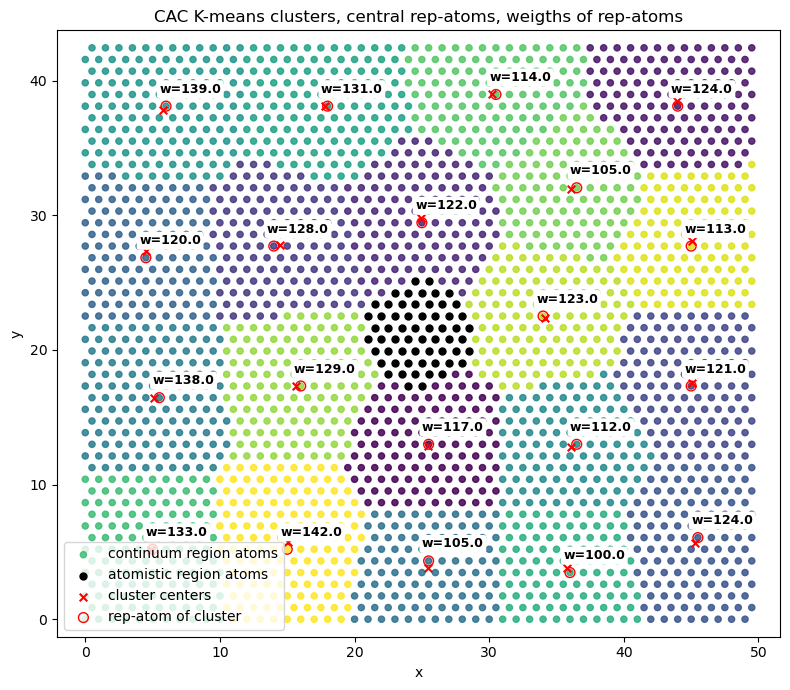

In [8]:
plot_clusters(
    atoms=atoms,
    defect_atoms=defect_atoms,
    continuum_atoms=continuum_atoms,
    cluster_idx=cluster_idx,
    centers=centers,
    rep_atoms=rep_atoms,
    weights=weights,
)

In [9]:
# Export an animated GIF of K-means representative atom selection.
def export_kmeans_gif(
    continuum_atoms,
    defect_atoms,
    frame_history,
    output_path="cac_kmeans.gif",
    interval=700,
    fps=2,
):
    """
    Parameters:
        continuum_atoms: coords of atoms being clustered
        defect_atoms: coords of fully atomistic atoms
        frame_history: output from kmeans_representative_atoms_with_history
        output_path: gif filename
        interval: delay between frames in milliseconds for preview
        fps: frames per second in exported GIF
    """

    fig, ax = plt.subplots(figsize=(8, 7))

    all_atoms = continuum_atoms
    if len(defect_atoms) > 0:
        all_atoms = np.vstack([continuum_atoms, defect_atoms])

    x_min, y_min = all_atoms.min(axis=0)
    x_max, y_max = all_atoms.max(axis=0)

    pad = 1.0
    ax.set_xlim(x_min - pad, x_max + pad)
    ax.set_ylim(y_min - pad, y_max + pad)
    ax.set_aspect("equal", adjustable="box")

    def update(frame_index):
        ax.clear()

        frame = frame_history[frame_index]
        cluster_idx = frame["cluster_idx"]
        centers = frame["centers"]
        J = frame["J"]
        iteration = frame["iteration"]

        # continuum region atoms
        ax.scatter(continuum_atoms[:, 0],continuum_atoms[:, 1],c=cluster_idx,s=20,alpha=0.75,label='continuum')

        # atomistic atoms
        if len(defect_atoms) > 0:
            ax.scatter(defect_atoms[:, 0],defect_atoms[:, 1],c="black",s=30,label="defect (fully atomistic)")

        # cluster centers
        ax.scatter(centers[:, 0],centers[:, 1],c="red",marker="x",s=40,linewidths=1.5,label="cluster centers")

        ax.set_xlim(x_min - pad, x_max + pad)
        ax.set_ylim(y_min - pad, y_max + pad)
        ax.set_aspect("equal", adjustable="box")

        ax.set_xlabel("x")
        ax.set_ylabel("y")
        ax.set_title(f"K-means rep-atom selection\niteration={iteration}, J={J:.4f}")
        # ax.legend(loc="best")
        ax.legend(bbox_to_anchor=(0.5, -0.1), loc='upper left')


        return ax

    anim = FuncAnimation(
        fig,
        update,
        frames=len(frame_history),
        interval=interval,
        repeat=True,
    )

    writer = PillowWriter(fps=fps)
    anim.save(output_path, writer=writer)

    plt.close(fig)

    print(f"Saved GIF to: {output_path}")

In [10]:
# Export animation
export_kmeans_gif(
    continuum_atoms=continuum_atoms,
    defect_atoms=defect_atoms,
    frame_history=frame_history,
    output_path="cac_kmeans.gif",
    interval=700,
    fps=1,
)

Saved GIF to: cac_kmeans.gif


![Alternative Text](figs/cac_kmeans.png)                ![Alternative Text](figs/cac_kmeans.gif)

## Is `J` a reliable measure of accuracy? 
- solve the same problem for increasing `n_rep`
- Does `J` decrease with increasing `n_rep`? If yes, then it's a good objective function to minimize. 

In [15]:
# Run K-means representative atom selection for different n_reps 

n_rep_arr = [4,8,16,32,64,128,256]
J_arr = []
for i in range(len(n_rep_arr)):
    n_rep = n_rep_arr[i]
    centers, cluster_idx, weights, rep_atom_indices_local, J_history, frame_history = kmeans_representative_atoms(
        continuum_atoms,
        n_rep=n_rep,
        max_iter=50,
        tol=1e-10,
        seed=7,
    )
    J_arr.append(J_history[-1])

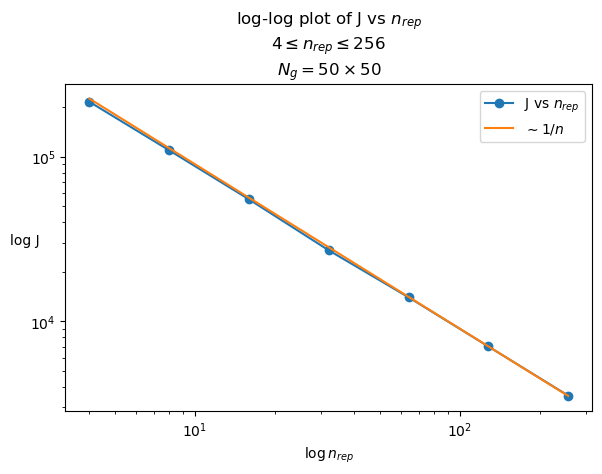

In [84]:
power_x = np.array(n_rep_arr)
power_y = 9e5*(power_x ** (-1.0))
plt.plot(n_rep_arr,J_arr,label='J vs $n_{rep}$', marker='o', linestyle='-',)
plt.plot(power_x,power_y,label='$\\sim 1/n$')
plt.xlabel("$\\log n_{rep}$")
plt.ylabel("log J",rotation=0)
plt.title("log-log plot of J vs $n_{rep}$\n$4 \\leq n_{rep} \\leq 256$\n$N_g=50 \\times 50$")
plt.legend(loc="best")
plt.tight_layout()
plt.yscale('log')
plt.xscale('log')
plt.savefig('J_vs_nrep.png')
plt.show()
